In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")
sub = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv")

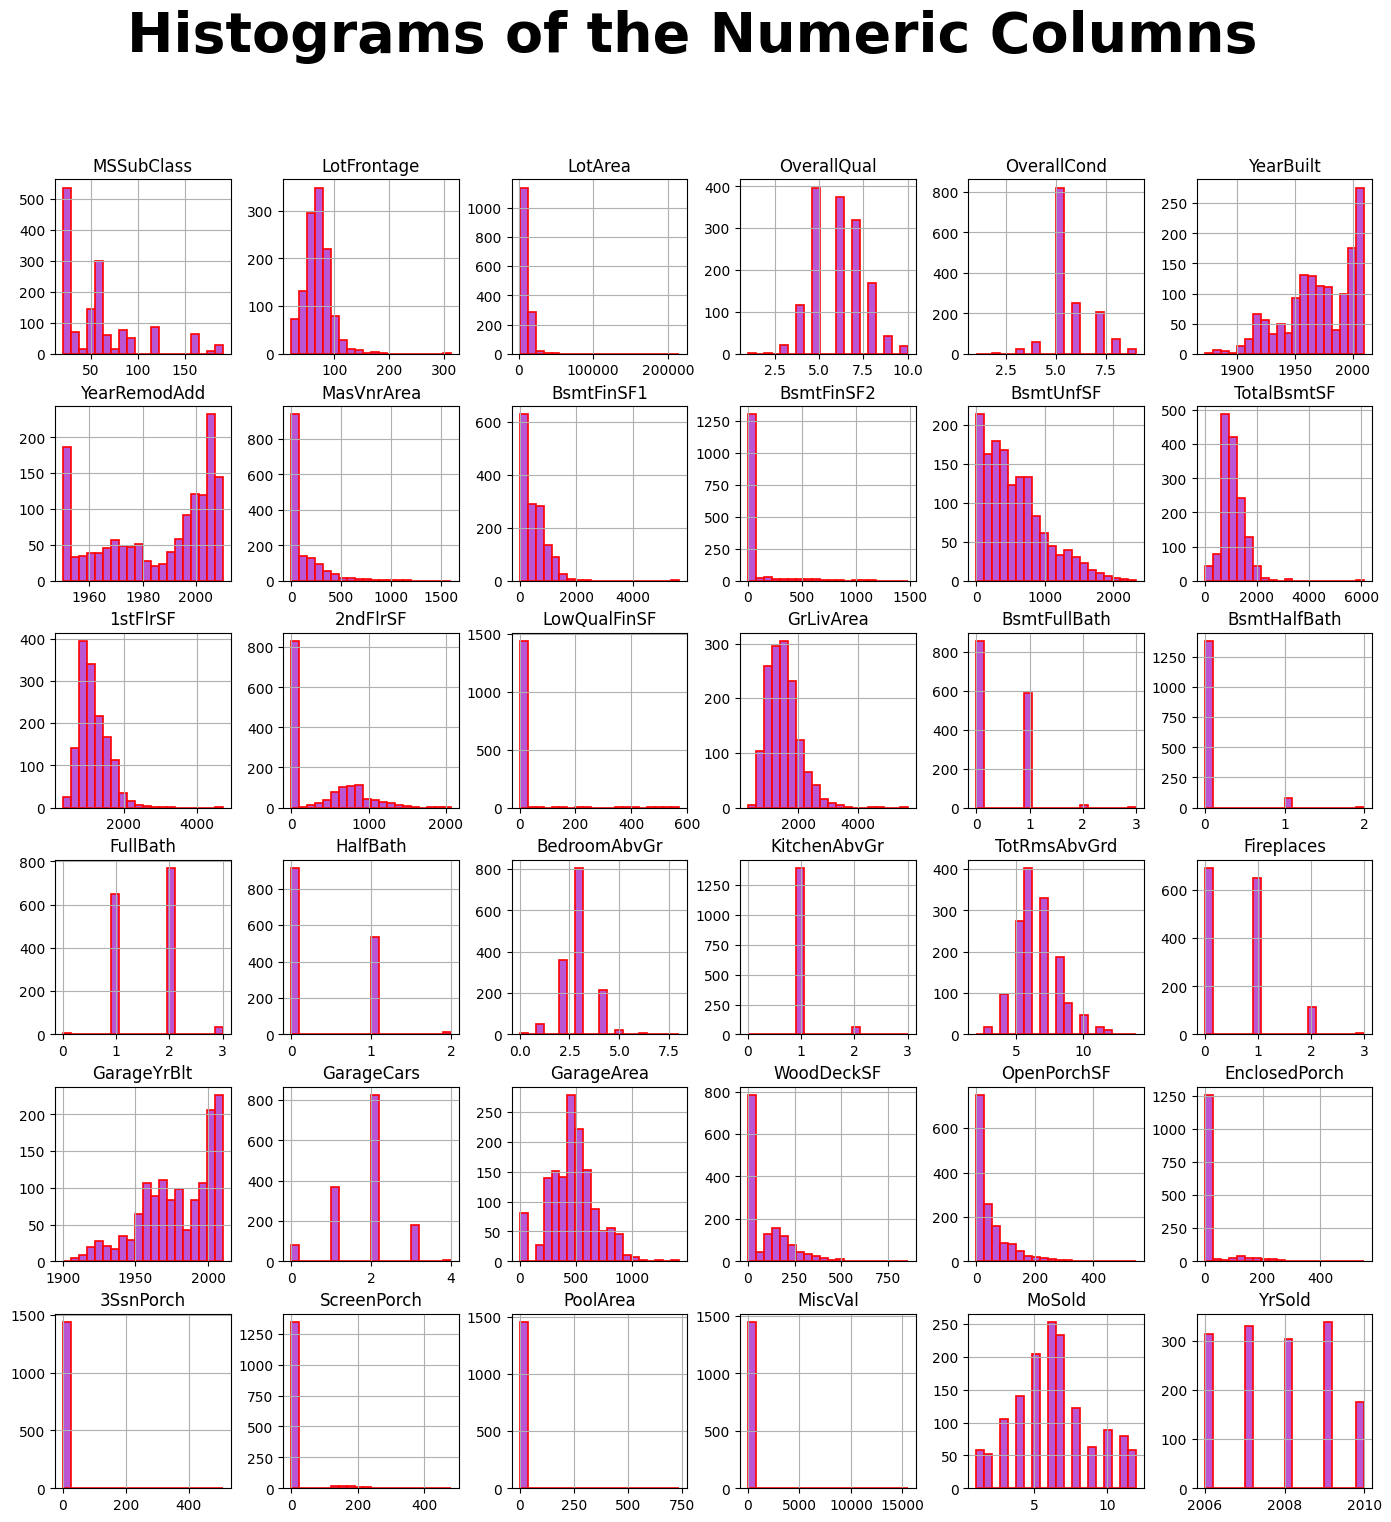

In [2]:
df.head()
numcols = df.describe().columns
numcols_without_id_target = numcols.drop(["Id", "SalePrice"])
df[numcols_without_id_target].hist(bins = 20 ,figsize = (17, 17), color="mediumorchid", edgecolor="red", linewidth=1.2)
plt.suptitle("Histograms of the Numeric Columns", fontsize=40, fontweight="bold")
plt.show()

In [3]:
df[numcols_without_id_target].skew()

MSSubClass        1.407657
LotFrontage       2.163569
LotArea          12.207688
OverallQual       0.216944
OverallCond       0.693067
YearBuilt        -0.613461
YearRemodAdd     -0.503562
MasVnrArea        2.669084
BsmtFinSF1        1.685503
BsmtFinSF2        4.255261
BsmtUnfSF         0.920268
TotalBsmtSF       1.524255
1stFlrSF          1.376757
2ndFlrSF          0.813030
LowQualFinSF      9.011341
GrLivArea         1.366560
BsmtFullBath      0.596067
BsmtHalfBath      4.103403
FullBath          0.036562
HalfBath          0.675897
BedroomAbvGr      0.211790
KitchenAbvGr      4.488397
TotRmsAbvGrd      0.676341
Fireplaces        0.649565
GarageYrBlt      -0.649415
GarageCars       -0.342549
GarageArea        0.179981
WoodDeckSF        1.541376
OpenPorchSF       2.364342
EnclosedPorch     3.089872
3SsnPorch        10.304342
ScreenPorch       4.122214
PoolArea         14.828374
MiscVal          24.476794
MoSold            0.212053
YrSold            0.096269
dtype: float64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


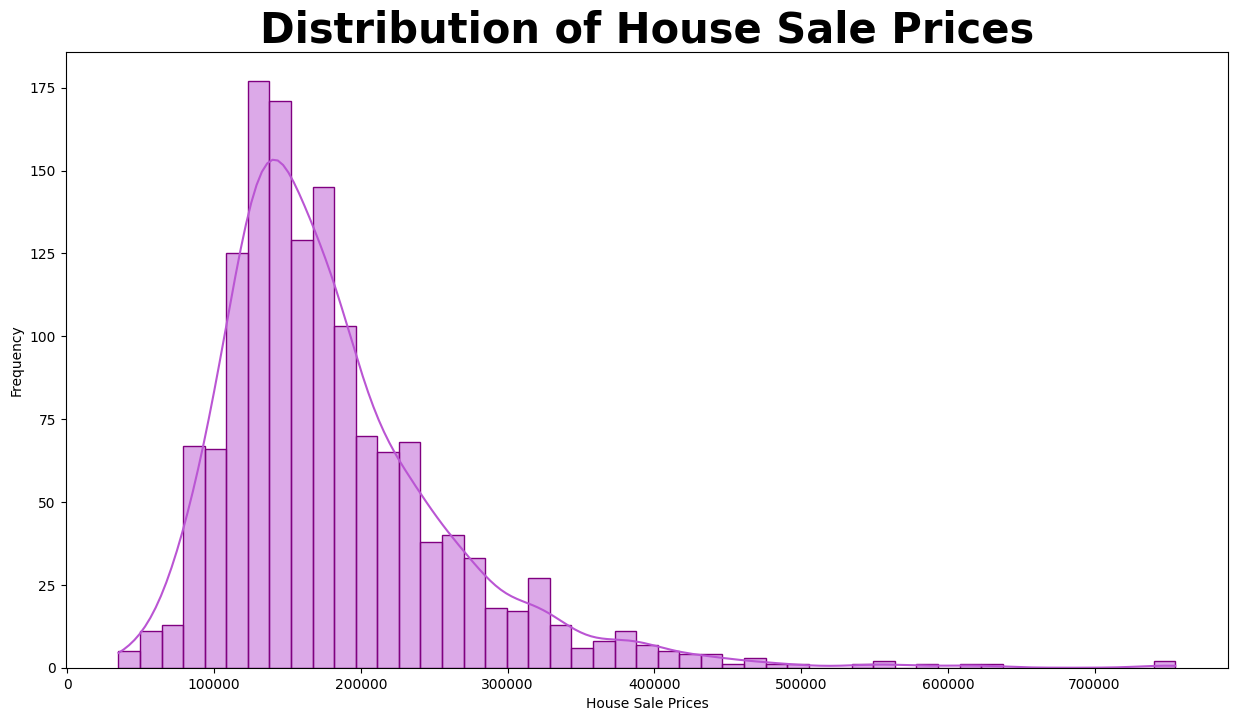

In [4]:
plt.figure(figsize=(15, 8))
sns.histplot(df["SalePrice"], kde=True, color="mediumorchid", edgecolor="purple", linewidth=1)
plt.title("Distribution of House Sale Prices", fontweight = "bold" , fontsize=30)
plt.ylabel("Frequency")
plt.xlabel("House Sale Prices")
plt.show()

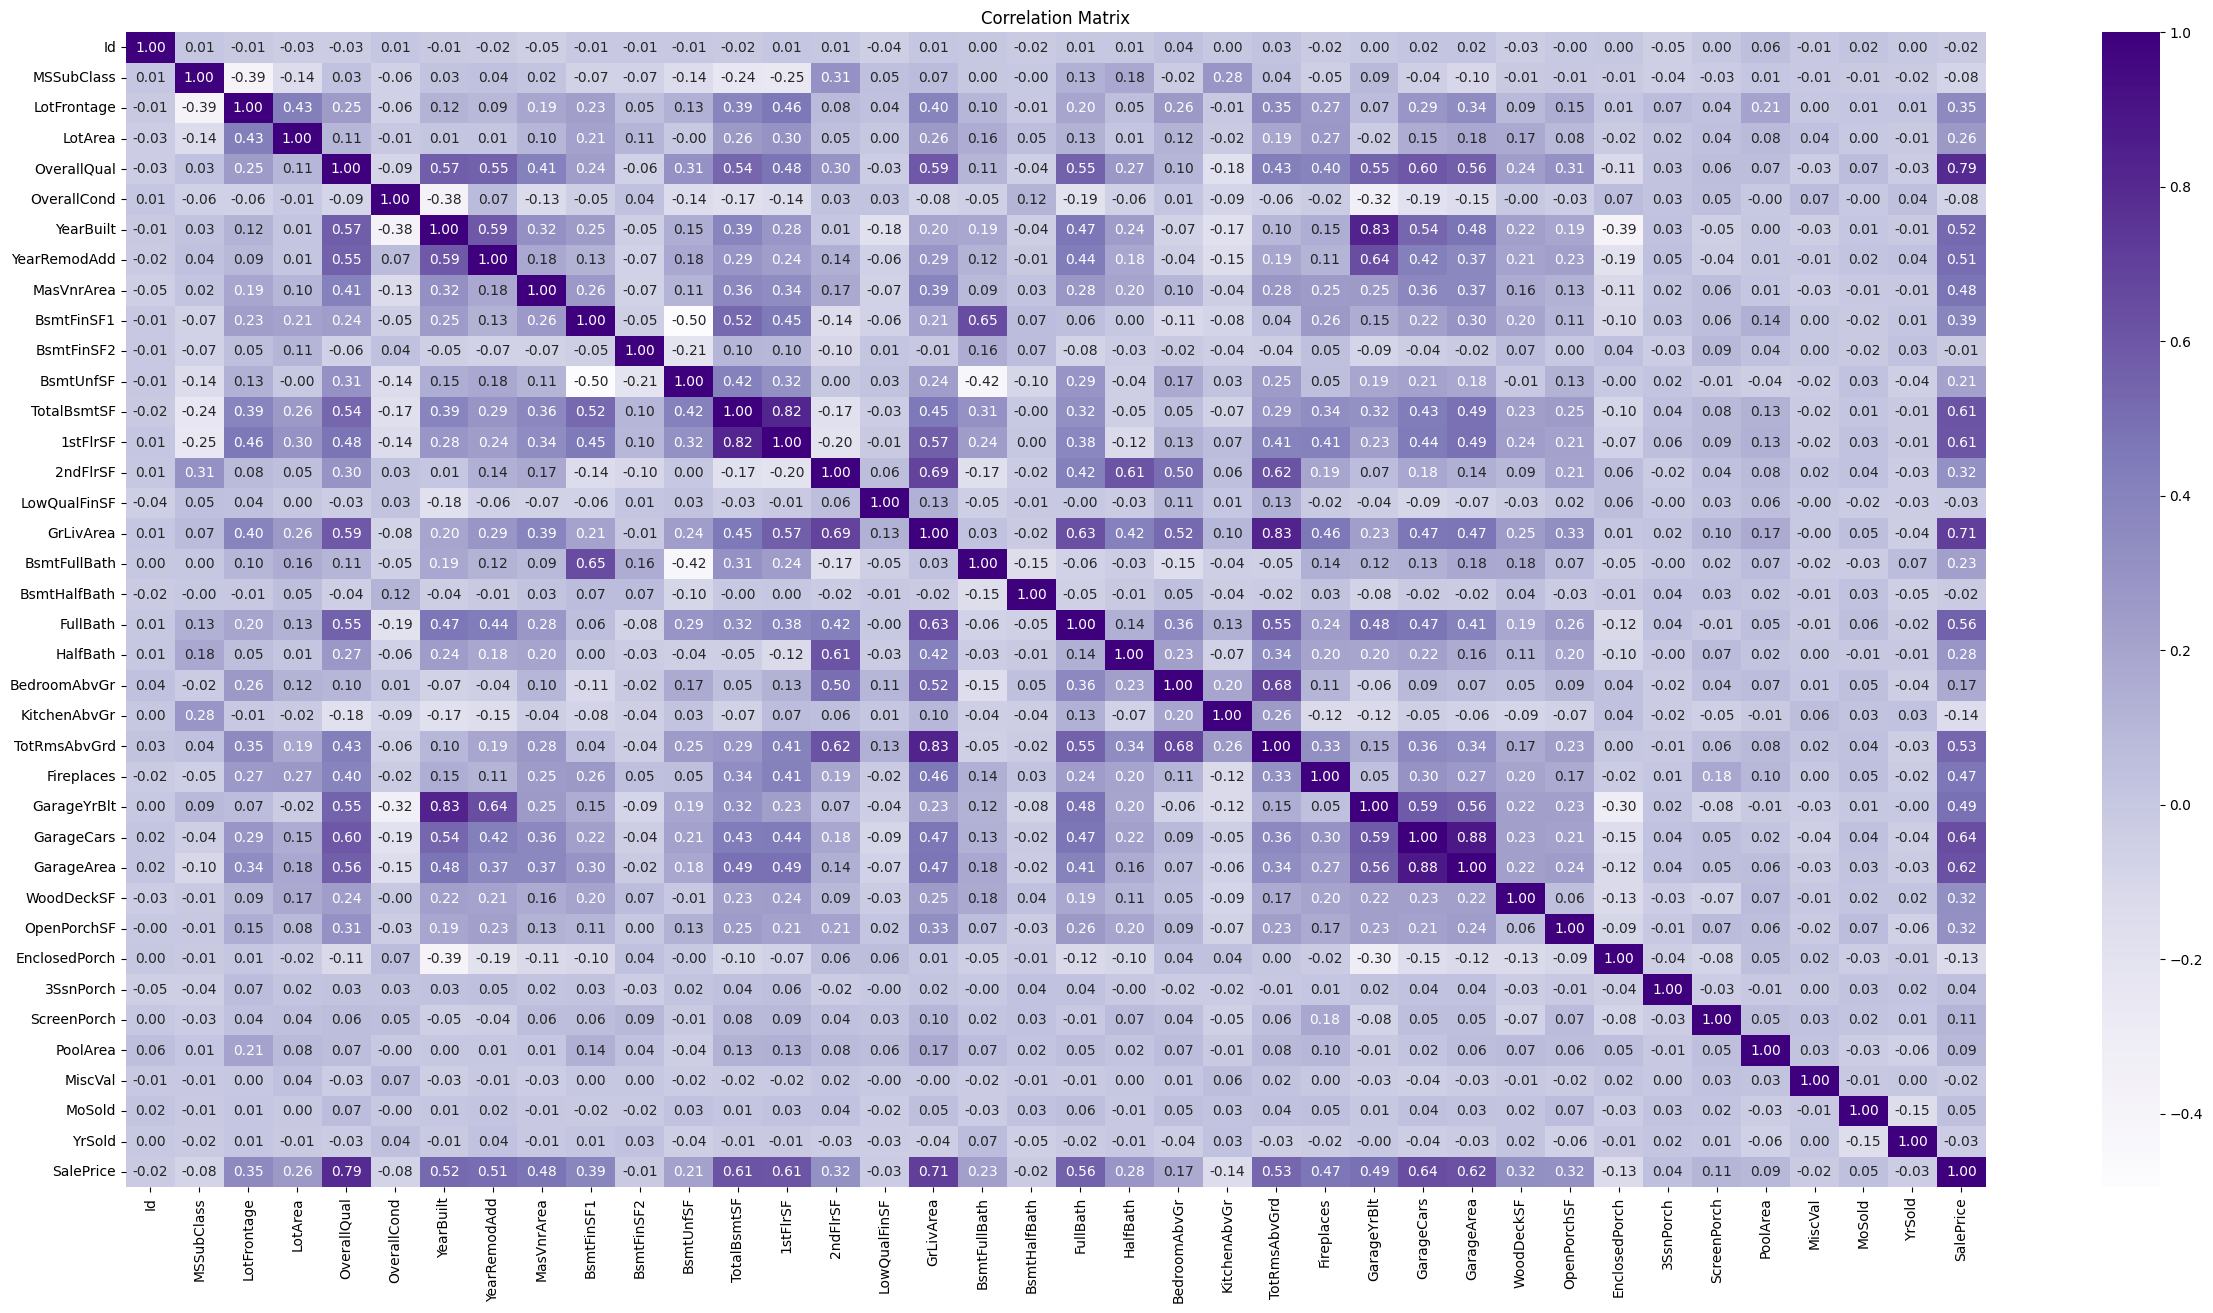

In [5]:
plt.figure(figsize=(30, 15))
corr = df[numcols].corr()
sns.heatmap(corr, annot=True, cmap="Purples", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [6]:
#missing values percentage per column
df.isna().sum()[df.isna().sum() > 0]/len(df)*100

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

In [7]:
#import transformer
from sklearn.preprocessing import FunctionTransformer

#drop columns
drop_cols = ["Id", "Alley", "PoolQC", "Fence", "MiscFeature"]

#feature engineering function
def added_features(df):
    df_out = df.copy()

    #drop high null columns
    df_out.drop(columns=drop_cols, errors="ignore")
    
    #age
    df_out["PropertyAge"] = df_out["YrSold"] - df_out["YearBuilt"]

    #area
    df_out["TotalSF"] = df_out["TotalBsmtSF"] + df_out["1stFlrSF"] + df_out["2ndFlrSF"]
    df_out["TotalBath"] = df_out["FullBath"] + 0.5 * df_out["HalfBath"] + df_out["BsmtFullBath"] + 0.5 * df_out["BsmtHalfBath"]

    #remodeled? 
    df_out["HasRemodeled"] = (df_out["YearRemodAdd"] != df_out["YearBuilt"]).astype(object)

    # binary features for property amenities
    df_out["HasPool"] = (df_out["PoolArea"] > 0).astype(int)
    df_out["HasBasement"] = (df_out["TotalBsmtSF"] > 0).astype(int)
    df_out["HasFireplace"] = (df_out["Fireplaces"] > 0).astype(int)
    df_out["Has2ndFloor"] = (df_out["2ndFlrSF"] > 0).astype(object)
    df_out["HasGarage"] = (df_out["GarageArea"] > 0).astype(object)

    # convert some numeric features to categorical
    df_out["YrSold_cat"] = df_out["YrSold"].astype(object)
    df_out["MoSold_cat"] = df_out["MoSold"].astype(object)
    df_out["YearBuilt_cat"] = df_out["YearBuilt"].astype(object)
    df_out["MSSubClass_cat"] = df_out["MSSubClass"].astype(object)

    #GOQ
    df_out["OverallGrade"] = df_out["OverallQual"] * df_out["OverallCond"]
    df_out["QualityArea"] = df_out["OverallQual"] * df_out["GrLivArea"]
    
    
    return df_out


#wrap feature engineering into transformer
feature_transformer = FunctionTransformer(added_features)

In [8]:
#update categorical and numerical columns
new_cols_categorical = pd.Index(["HasRemodeled", "Has2ndFloor", "HasGarage",
                                 "YrSold_cat", "MoSold_cat", "YearBuilt_cat",
                                 "MSSubClass_cat"])
new_cols_numeric = pd.Index(["PropertyAge", "TotalSF", "TotalBath", 
                             "HasFireplace", "HasBasement", "HasPool",
                             "OverallGrade", "QualityArea"])


categorical_columns = df.select_dtypes(include=["object", "category"]).columns.append(new_cols_categorical)
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.append(new_cols_numeric)


#drop target column from numerics
numerical_columns = numerical_columns.drop("SalePrice")

In [9]:
#import sklearn tools for preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#categorical pipeline
cat_transform = Pipeline(steps = [
                                  ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
                                  ("onehot", OneHotEncoder(handle_unknown="ignore", sparse = False))
                                 ])

#numerical pipeline
num_transform = Pipeline(steps = [
                                  ("imputer", SimpleImputer(strategy="mean")),
                                  ("scaler", StandardScaler())
                                 ])

In [10]:
#combine preprocessing pipelines

preprocessor = ColumnTransformer(transformers=[("cat", cat_transform, categorical_columns),
                                               ("num", num_transform, numerical_columns)
                                               ], 
                                                 remainder = "passthrough")

#create full pipeline with feature engineering

pipeline = Pipeline(steps=[
    ("engineer", feature_transformer),
    ("preprocessor", preprocessor)])

#apply pipeline to dataset
X = df.drop("SalePrice", axis=1)
y = np.log(df["SalePrice"]) #normalize dependent variable 
X_preprocessed = pipeline.fit_transform(X)
test_preprocessed = pipeline.transform(test)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [ ]:
#import models and tools for training
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, ElasticNet, ElasticNetCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error
import optuna

In [ ]:
#define objectives for Optuna
objectives = {}

#LightGBM objective
def objective_lgbm(trial):
    params = {
        "n_estimators": 1000,
        "random_state": 42,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", -1, 15),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "verbose": -1
    }
    model = LGBMRegressor(**params)
    score = -cross_val_score(model, X_preprocessed, y,
                             cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["LightGBM"] = objective_lgbm

#Ridge Objective
def objective_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
    model = Ridge(alpha=alpha, random_state=132)
    score = -cross_val_score(model, X_preprocessed, y,
                             cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["Ridge"] = objective_ridge


#ElasticNet Objective
def objective_elastic(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.1, 1.0)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                       random_state=132, max_iter=20000)
    score = -cross_val_score(model, X_preprocessed, y,
                             cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["ElasticNet"] = objective_elastic

#Kernel Ridge Regression Objective
def objective_krr(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 10.0, log=True)
    kernel = trial.suggest_categorical("kernel", ["linear", "polynomial", "rbf"])
    if kernel == "polynomial":
        degree = trial.suggest_int("degree", 2, 5)
        coef0 = trial.suggest_float("coef0", 0.0, 5.0)
        model = KernelRidge(alpha=alpha, kernel=kernel, degree=degree, coef0=coef0)
    else:
        model = KernelRidge(alpha=alpha, kernel=kernel)
    score = -cross_val_score(model, X_preprocessed, y,
                             cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["KernelRidge"] = objective_krr

#XGBoost Objective
def objective_xgb(trial):
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "device": "cuda",
        "random_state": 42,
        "n_estimators": 1000,
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }
    model = XGBRegressor(**params)
    score = -cross_val_score(model, X_preprocessed, y,
                             cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["XGBoost"] = objective_xgb

In [ ]:
#Run Optuna Hyperparameter Optimization
best_params = {}
best_scores = {}

for name, objective in objectives.items():
    print(f"\n Optimizing {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=5, show_progress_bar=True) 
    # Best params were found with 150 n_trials.
    
    best_params[name] = study.best_params
    best_scores[name] = study.best_value
    
    print(f"{name} best RMSE: {study.best_value:.5f}")
    print(f"Best params: {study.best_params}")

In [ ]:
# Best Hyperparameters from Optuna Optimization
best_params_dict = {
    "Ridge": {'alpha': 6.577845021836757}, 
    
    "ElasticNet": {'alpha': 0.001175898057027851, 
                   'l1_ratio': 0.2556675520546301},
    
    "KernelRidge": {'alpha': 0.1476316691169565, 
                    'kernel': 'polynomial', 
                    'degree': 2, 
                    'coef0': 2.082659943772578},
    
    "XGBoost": {'max_depth': 4, 
                'learning_rate': 0.02373014388999918,
                'subsample': 0.8423921813587263, 
                'colsample_bytree': 0.5228354076316597,
                'reg_alpha': 0.00014172841523401867, 
                'reg_lambda': 0.008005196902006313},
    
    "LightGBM": {'learning_rate': 0.06234817414958063, 
                 'num_leaves': 278, 
                 'max_depth': 2, 
                 'subsample': 0.593312100941863, 
                 'colsample_bytree': 0.7497991100268827, 
                 'reg_alpha': 0.0001354219967120134, 
                 'reg_lambda': 5.097599798916927, 
                 'verbose': -1}
}

In [ ]:
#Initialize Tuned Models with Best Hyperparameters
tuned_models = [
    ("Ridge", Ridge(**best_params_dict["Ridge"], random_state=132)),
    ("ElasticNet", ElasticNet(**best_params_dict["ElasticNet"], random_state=132, max_iter=20000)),
    ("KernelRidge", KernelRidge(**best_params_dict["KernelRidge"])),
    ("XGBoost", XGBRegressor(**best_params_dict["XGBoost"], random_state=132)),
    ("LightGBM", LGBMRegressor(**best_params_dict["LightGBM"], random_state=132))
]

In [ ]:
#Out-of-Fold (OOF) Cross-Validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
oof_preds = {name: np.zeros(len(X)) for name, _ in tuned_models}

#Train Tuned Models with K-Fold CV
for name, model in tuned_models:
    print(f"Training tuned model: {name}")
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_preprocessed, y), 1):
        X_tr, X_val = X_preprocessed[tr_idx], X_preprocessed[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        oof_preds[name][val_idx] = preds
        

    #Evaluate each Model with RMSE

    rmse = np.sqrt(mean_squared_error(y, oof_preds[name]))
    print(f"{name} OOF RMSE: {rmse:.5f}")

In [ ]:
#Create Out-of-Fold (OOF) Features for Stacking
X_meta = pd.DataFrame(oof_preds)

#Define Objective for Meta-Model (ElasticNet)
def objective_meta(trial):
    # Suggest hyperparameters
    alpha = trial.suggest_float("alpha", 1e-5, 1.0, log=True)    # smaller range can help fine-tune regularization
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)    # balance between L1 and L2

    # Define meta model
    meta_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=20000)
    
    # Cross-validation on OOF preds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    preds = np.zeros_like(y, dtype=float)
    
    for tr_idx, val_idx in kf.split(X_meta):
        X_tr, X_val = X_meta.iloc[tr_idx], X_meta.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        meta_model.fit(X_tr, y_tr)
        preds[val_idx] = meta_model.predict(X_val)
    
    score = np.sqrt(mean_squared_error(y, preds))
    return score

#Run Optuna Optimization for Meta-Model
study = optuna.create_study(direction="minimize")
study.optimize(objective_meta, n_trials=150, show_progress_bar=True)

In [ ]:
# Display Best meta model Results
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

In [ ]:
#Train Final Meta-Model with Best Hyperparameters
best_meta = ElasticNet(**study.best_params, random_state=42, max_iter=20000)
best_meta.fit(X_meta, y)

#Evaluate Stacked Meta-Model on Training Data
meta_pred = best_meta.predict(X_meta)
meta_rmse = np.sqrt(mean_squared_error(y, meta_pred))
print(f"Final Meta-model RMSE: {meta_rmse:.5f}")

In [ ]:
#Generate Test Set Predictions for Base Models
test_meta = pd.DataFrame({name: model.predict(test_preprocessed) for name, model in tuned_models})

#Predict with Stacked Meta-Model
stack_pred = best_meta.predict(test_meta)
final_pred = np.expm1(stack_pred) # Reverse log-transform


In [ ]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": final_pred
})
submission.to_csv("submission.csv", index=False)

print("File Created")
print("="*50)
print("First 5 rows of the submission file:")
submission.head()